# Generate Transition Plots

In [1]:
import os
import sys

sys.path.append('..')
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
import numpy as np
import random
import pylab as plt
import tqdm

from coronal_diffusion import dataset
from coronal_diffusion import visualization_tools as vt
from coronal_diffusion import sampler

import config

/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/ai/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def set_seeds(seed):
    torch.use_deterministic_algorithms(True)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [3]:
set_seeds(0)

/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [4]:
os.chdir('..')
print('Current directory is:', os.getcwd())

Current directory is: /home/dedasilv/coronal-diffusion-modeling


In [5]:
sampling_data = sampler.load_sampling_data()

In [6]:
imgs, _ = sampler.sample(
    weights_file='checkpoints/experiment59-cs-fix-and-context-scaling_16.pth',
    sampling_data=sampling_data,
    context=(50, 50, 10, 10, 1, -1),
    method='ddpm',
    return_history=True
)

Denoising Step 1                 
Fitting spherical harmonics (45)


In [7]:
imgs.shape

(1001, 16, 90, 180)

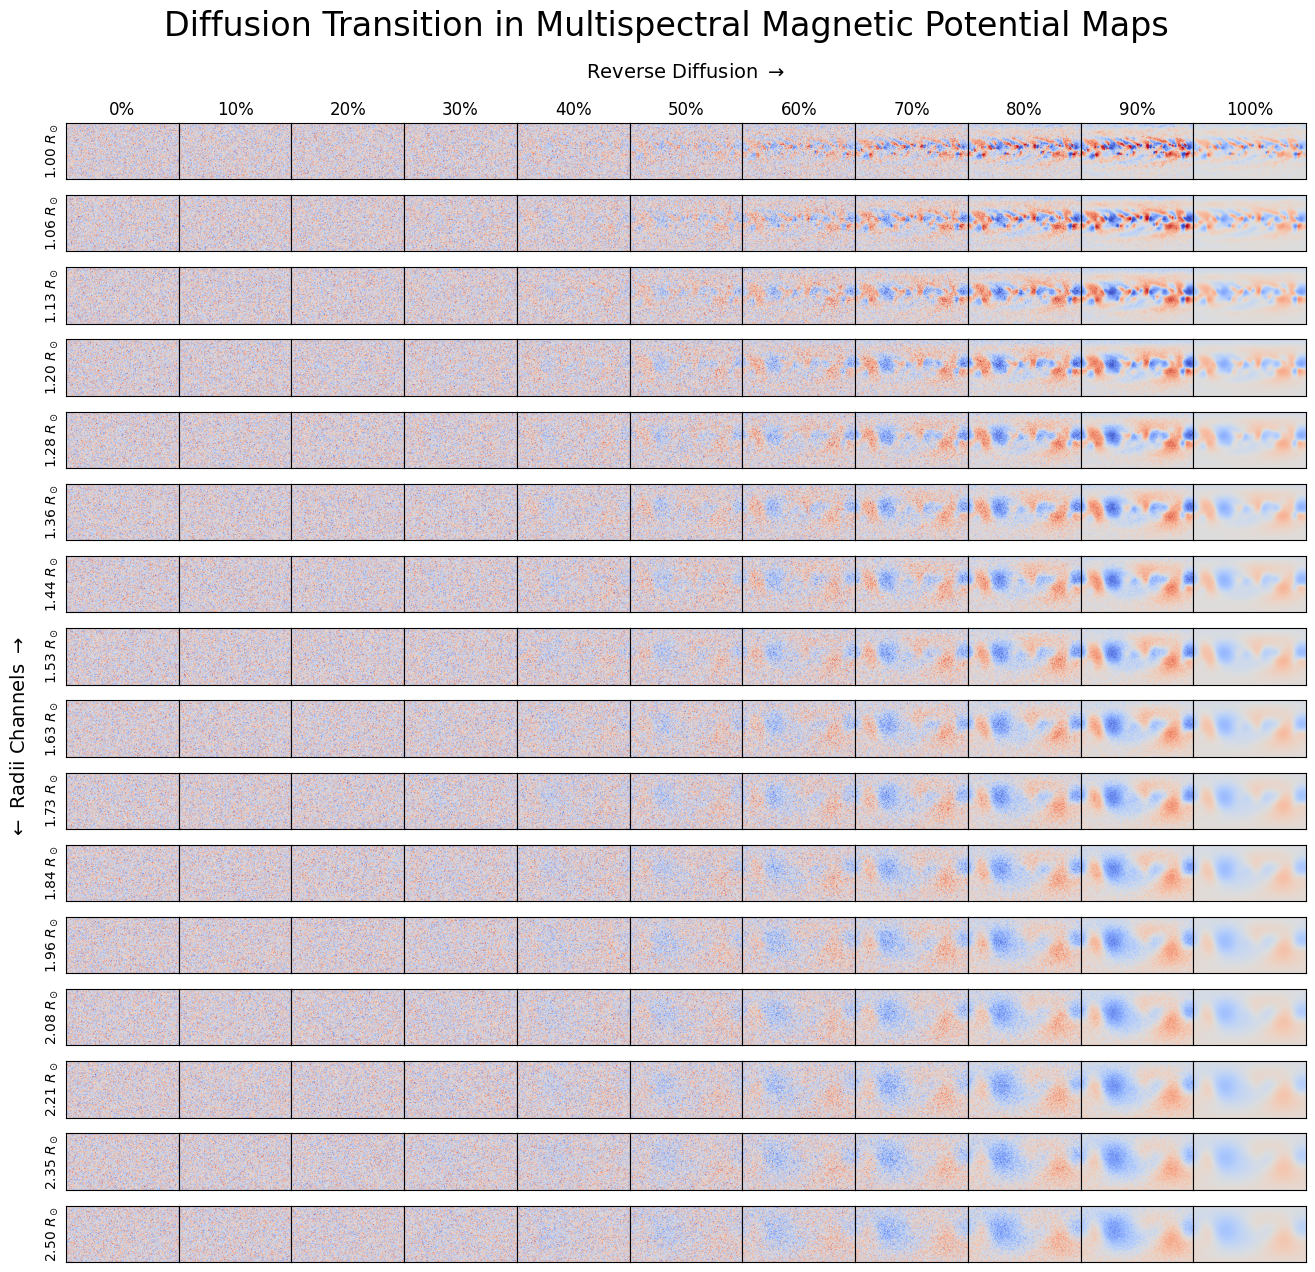

In [9]:
n = 10

fig, axes = plt.subplots(config.radii.size, n + 1, figsize=(16, 15))
L = np.abs(imgs).max() * 0.5
axes = axes

for j in range(config.radii.size):
    for i in range(n + 1):
        axes[j, i].imshow(imgs[i*1000//n][j], origin='lower', cmap='coolwarm', vmin=-L, vmax=L)    
        axes[j, i].set_xticks([])
        axes[j, i].set_yticks([])
        if j == 0:
            axes[j, i].set_title(f'{100*i / n:.0f}%')
    axes[j, 0].set_ylabel(f'{config.radii[j]:.2f} $R_\\odot$', fontsize=10)
plt.subplots_adjust(wspace=0.0, hspace=.0)
fig.suptitle('Diffusion Transition in Multispectral Magnetic Potential Maps', fontsize=24, y=0.95)
fig.text(s='Reverse Diffusion $\\rightarrow$', fontsize=14, x=0.45, y=0.905)
fig.text(s='$\\leftarrow$ Radii Channels $\\rightarrow$', fontsize=14, x=0.09, y=0.4, rotation=90)
fig.savefig('plots/paper/transition.png', dpi=300, bbox_inches='tight')